<a href="https://www.kaggle.com/code/tltommu/notebook-for-distributed-signal-coherence-classifi?scriptVersionId=302710472" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import matthews_corrcoef
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tltommu/distributed-signal-coherence-classification/sample_submission.csv
/kaggle/input/datasets/tltommu/distributed-signal-coherence-classification/train.csv
/kaggle/input/datasets/tltommu/distributed-signal-coherence-classification/test.csv


In [2]:
pd.read_csv('/kaggle/input/datasets/tltommu/distributed-signal-coherence-classification/test.csv')


,sample_id,process.b1.capacity_x_process.b2.capacity,process.b1.capacity_ratio_process.b2.capacity,process.b1.capacity_x_process.b3.capacity,process.b1.capacity_ratio_process.b3.capacity,process.b1.capacity_x_process.b4.capacity,process.b1.capacity_ratio_process.b4.capacity,process.b1.capacity_x_property.price,process.b1.capacity_ratio_property.price,process.b1.capacity_x_property.product,...,random_noise_5,random_noise_6,random_noise_7,random_noise_8,random_noise_9,random_noise_10,random_noise_11,random_noise_12,random_noise_13,random_noise_14
0,0,2.178607,0.439623,2.033214,0.543062,1.056887,1.016784e+00,73.998972,0.004502,4.093000,...,0.238476,3.643646,0.004983,-2.097921,1.617765,-0.912058,-0.711742,-1.162209,1.240261,-0.666210
1,1,2.204091,0.507852,2.002479,0.627290,-0.036475,1.083820e+06,74.237207,0.006372,4.451880,...,-0.376751,0.282916,-0.035184,0.347988,2.066045,0.590751,-2.063643,2.366036,-1.561095,-0.901217
2,2,3.203485,0.339315,2.066744,0.518448,0.964339,9.948591e-01,72.678646,0.025834,4.414540,...,1.114098,1.206694,0.007919,-1.246005,-1.343607,-1.023337,1.731129,0.204953,-1.348029,-0.144012
3,3,3.040778,0.426908,2.104334,0.624002,-0.008017,1.057143e+06,75.953188,-0.028452,4.351062,...,0.800828,-2.748490,0.277542,0.024963,0.908182,0.287784,-1.351104,-1.442729,-0.339592,-1.574358
4,4,4.070305,1.099774,4.064316,1.043053,1.998912,2.093030e+00,154.259234,0.020605,8.037289,...,0.092986,-0.988575,-0.201977,-0.488347,-0.860862,-0.435518,0.408942,1.410126,0.173982,-0.448312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,812,0.024397,0.005302,-0.019939,0.012331,0.028572,5.919905e-02,0.023096,0.004084,-0.030260,...,1.903382,-1.172625,-0.664446,-1.063102,-1.899829,-2.025201,0.321178,1.825929,-0.563010,0.244462
813,813,1.001111,1.026344,2.023683,0.548172,-0.016841,1.093428e+06,76.619660,0.039909,3.320137,...,-0.830379,-1.538770,-0.611500,1.558845,-1.455961,0.661363,0.369363,1.232741,-1.127645,-0.706099
814,814,5.981768,0.710029,4.334893,1.039286,2.054477,2.108115e+00,142.998800,0.061646,4.164676,...,0.171515,1.405586,0.126701,-0.735385,-0.847642,-0.622737,1.261230,-0.057908,1.051454,-0.133289
815,815,2.177793,0.455452,2.171771,0.527482,1.107308,1.058291e+00,73.958067,0.040552,6.225434,...,0.849755,-1.029253,0.083633,1.039286,-0.282133,-0.453002,-0.510429,-1.336224,-2.466040,-0.818201


In [3]:
pd.read_csv('/kaggle/input/datasets/tltommu/distributed-signal-coherence-classification/train.csv')


,sample_id,signal_incoherence_flag,process.b1.capacity_x_process.b2.capacity,process.b1.capacity_ratio_process.b2.capacity,process.b1.capacity_x_process.b3.capacity,process.b1.capacity_ratio_process.b3.capacity,process.b1.capacity_x_process.b4.capacity,process.b1.capacity_ratio_process.b4.capacity,process.b1.capacity_x_property.price,process.b1.capacity_ratio_property.price,...,random_noise_5,random_noise_6,random_noise_7,random_noise_8,random_noise_9,random_noise_10,random_noise_11,random_noise_12,random_noise_13,random_noise_14
0,0,0,0.024709,-0.019760,-0.026310,-0.004135,-0.006730,0.001251,-0.044223,0.004690,...,0.503761,-0.201693,-0.657262,-1.027193,-0.153803,0.040005,-0.103077,0.321227,1.539070,-0.095956
1,1,0,-0.036630,-0.020456,-0.021800,0.041245,-0.011833,-0.003861,0.001455,0.014717,...,-1.072834,-0.709477,-0.415700,-0.769811,-1.197727,0.817170,0.945032,-0.593632,0.908067,-0.408795
2,2,0,-0.048730,-0.024179,0.022519,0.037415,-0.012775,-0.028042,-0.020358,0.016098,...,-0.088900,-0.131802,0.914596,-0.666608,1.802507,0.083695,1.528015,-1.126418,-0.281239,0.818465
3,3,0,0.052933,-0.031357,-0.038000,0.023128,-0.094375,-0.023374,0.087891,-0.005552,...,0.760558,-0.195701,1.390972,-0.549157,-0.214910,0.158294,0.570704,-0.062690,-0.439609,0.409966
4,4,0,-0.013465,0.014689,0.015525,-0.034601,0.012456,-0.052177,-0.005970,-0.054419,...,-0.440666,0.485047,0.817559,1.976042,-0.489618,0.233686,0.801215,1.501521,-1.417762,-2.796192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1221,1221,0,5.924691,0.649638,3.974799,1.065317,2.061835,1.962396,172.003828,0.072012,...,-0.043344,-0.395881,1.635279,-0.695995,0.797310,0.299709,-1.169343,0.326605,0.724666,-0.423773
1222,1222,0,5.829414,0.678248,4.054136,0.988816,2.003874,2.012559,173.899226,-0.015919,...,-0.730471,-0.273866,-0.648202,1.050015,0.738605,0.460258,-1.315331,1.967986,-0.167377,0.537125
1223,1223,0,6.030075,0.693856,3.859125,1.015598,2.079464,1.987554,173.989111,0.019333,...,-1.090981,-0.993066,-0.694385,-0.940450,-0.289349,0.923849,0.496154,-1.778430,-0.421429,0.606000
1224,1224,0,5.989740,0.678100,3.970239,1.034929,1.986378,1.979633,176.043112,0.099575,...,2.381998,-2.213929,0.868929,-1.257331,0.530811,0.613272,-1.299619,-0.055353,-1.313546,-1.139804


<Axes: >

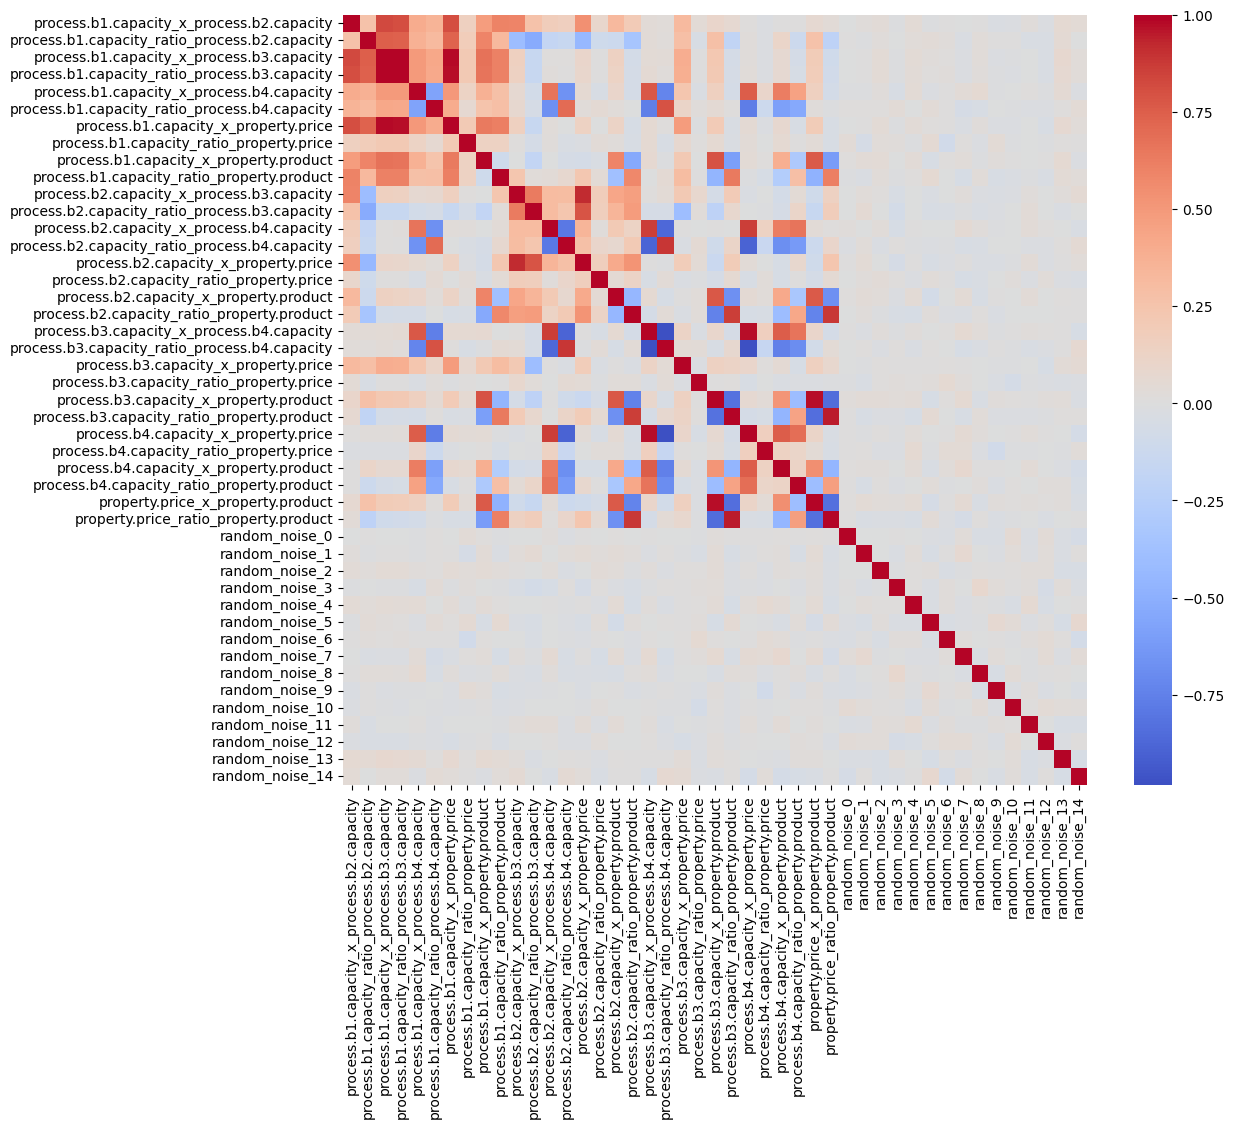

In [4]:
test = pd.read_csv('/kaggle/input/datasets/tltommu/distributed-signal-coherence-classification/test.csv')
train = pd.read_csv('/kaggle/input/datasets/tltommu/distributed-signal-coherence-classification/train.csv')

X = train.drop(["sample_id", "signal_incoherence_flag"], axis=1)
noise_cols = [col for col in train.columns if "random_noise" in col]

train = train.drop(columns=noise_cols)
test  = test.drop(columns=noise_cols)
y = train["signal_incoherence_flag"]
corr_matrix = X.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)

In [5]:
RANDOM_STATE = 42
N_SPLITS = 7
TARGET = "signal_incoherence_flag"
ID_COL = "sample_id"

def optimize_threshold(y_true, y_probs):
    low = np.percentile(y_probs, 50)
    high = np.percentile(y_probs, 99)

    thresholds = np.linspace(low, high, 400)
    best_mcc = 0
    best_thr = 0.5

    for thr in thresholds:
        preds = (y_probs > thr).astype(int)
        mcc = matthews_corrcoef(y_true, preds)

        if mcc > best_mcc:
            best_mcc = mcc
            best_thr = thr

    return best_thr, best_mcc


In [6]:
def train_lgbm(X, y, X_test):

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))

    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):

        print(f"\n========== LGBM Fold {fold+1} ==========")

        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

        model = lgb.LGBMClassifier(
            n_estimators=300,
            learning_rate=0.008,
            num_leaves=256,
            min_child_samples=3,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=pos_weight,
            random_state=RANDOM_STATE,
            verbosity=-1
        )

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="binary_logloss",
            callbacks=[lgb.early_stopping(100, verbose=False)]
        )

        oof_preds[valid_idx] = model.predict_proba(X_valid)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / N_SPLITS

    return oof_preds, test_preds

In [7]:
def optimize_threshold(y_true, y_probs):

    low = np.percentile(y_probs, 5)
    high = np.percentile(y_probs, 99)

    thresholds = np.linspace(low, high, 500)

    best_mcc = -1
    best_threshold = 0.5

    for t in thresholds:
        preds = (y_probs > t).astype(int)
        score = matthews_corrcoef(y_true, preds)

        if score > best_mcc:
            best_mcc = score
            best_threshold = t

    return best_threshold, best_mcc

In [8]:
def run_pipeline(model_type="lgbm"):
    """
    model_type: "lgbm" or "logistic"
    """

    print("Loading data...")
    test = pd.read_csv('/kaggle/input/datasets/tltommu/distributed-signal-coherence-classification/test.csv')
    train = pd.read_csv('/kaggle/input/datasets/tltommu/distributed-signal-coherence-classification/train.csv')

    train.columns = train.columns.str.strip()
    test.columns = test.columns.str.strip()

    # Remove noise features automatically
    features = [col for col in train.columns if col not in [ID_COL, TARGET]]
    features = [col for col in features if "random_noise" not in col]

    X = train[features]
    y = train[TARGET]
    X_test = test[features]

    print("Using", len(features), "features")

    # Select model
    if model_type == "lgbm":
        oof_preds, test_preds = train_lgbm(X, y, X_test)
    elif model_type == "logistic":
        oof_preds, test_preds = train_logistic(X, y, X_test)
    else:
        raise ValueError("model_type must be 'lgbm' or 'logistic'")
    print("OOF min:", oof_preds.min())
    print("OOF max:", oof_preds.max())
    print("OOF mean:", oof_preds.mean())
    print("Positive rate:", y.mean())
    # Optimize MCC
    best_threshold, best_mcc = optimize_threshold(y, oof_preds)
    final_score = (best_mcc + 1) / 2

    print("\n====================================")
    print(f"Best MCC: {best_mcc:.5f}")
    print(f"Final Score (Scaled MCC): {final_score:.5f}")
    print(f"Optimal Threshold: {best_threshold:.2f}")
    print("====================================")
    globals().update({
        "oof_preds": oof_preds,
        "test_preds": test_preds,
        "best_threshold": best_threshold,
        "best_mcc": best_mcc
    })

    return oof_preds, test_preds, best_threshold, best_mcc



In [9]:
run_pipeline('lgbm')

Loading data...
Using 30 features

========== LGBM Fold 1 ==========

========== LGBM Fold 2 ==========

========== LGBM Fold 3 ==========

========== LGBM Fold 4 ==========

========== LGBM Fold 5 ==========

========== LGBM Fold 6 ==========

========== LGBM Fold 7 ==========
OOF min: 0.012791197004988509
OOF max: 0.21502630583828364
OOF mean: 0.02851215464492939
Positive rate: 0.02936378466557912

Best MCC: 0.09509
Final Score (Scaled MCC): 0.54754
Optimal Threshold: 0.06


(array([0.02926067, 0.02926067, 0.02926067, ..., 0.02926067, 0.02245371,
        0.02926067]),
 array([0.0249101 , 0.02566581, 0.02496495, 0.0253188 , 0.02373829,
        0.02397028, 0.02690054, 0.02669657, 0.0242666 , 0.0242742 ,
        0.02380099, 0.02678147, 0.03799939, 0.02984702, 0.02562048,
        0.02823243, 0.03114586, 0.04601044, 0.02369738, 0.02399704,
        0.02798832, 0.02707193, 0.02369144, 0.02369825, 0.02592523,
        0.02683439, 0.02491322, 0.02693827, 0.02698535, 0.02688443,
        0.02369841, 0.03050324, 0.03067315, 0.02639741, 0.02900994,
        0.02411516, 0.02467865, 0.02453357, 0.03730429, 0.02380643,
        0.02388668, 0.02369852, 0.02369857, 0.02369823, 0.02394277,
        0.04283485, 0.02369586, 0.02369789, 0.0341929 , 0.02380807,
        0.02763758, 0.02374312, 0.02498942, 0.02416177, 0.03597286,
        0.02367914, 0.03031378, 0.04523017, 0.02434727, 0.02369835,
        0.02374683, 0.03231235, 0.04127279, 0.02516363, 0.02461339,
        0.027964  , 0

In [10]:
print("test_preds exists:", "test_preds" in globals())
print("best_threshold exists:", "best_threshold" in globals())

test_preds exists: True
best_threshold exists: True


In [11]:
final_test_preds = (test_preds > best_threshold).astype(int)

submission = pd.DataFrame({
    ID_COL: test[ID_COL],
    TARGET: final_test_preds
})

submission.to_csv("/kaggle/working/submission.csv", index=False)

print("Submission saved to /kaggle/working/submission.csv")

Submission saved to /kaggle/working/submission.csv
